## 1. Imports

# Bengaluru House Price Prediction

Predicts house prices in Bengaluru using a linear regression model, trained on the Kaggle *Bengaluru House Data* dataset.

**Pipeline:** data cleaning -> feature engineering -> outlier removal -> one-hot encoding -> model selection (GridSearchCV) -> prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Data

In [2]:
df = pd.read_csv("/content/Bengaluru_House_Data.csv")

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df.shape

(13320, 9)

## 3. Data Cleaning
Drop unused columns and handle missing values.

In [5]:
df1=df.drop(['society','area_type','availability','balcony'],axis=1)

In [6]:
df1.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [8]:
df1.isna().sum()

,0
location,1
size,16
total_sqft,0
bath,73
price,0


In [9]:
df1.dropna(inplace=True)
df1.isna().sum()

,0
location,0
size,0
total_sqft,0
bath,0
price,0


## 4. Feature Engineering
Parse `size` into a numeric `Bedroom` count and normalize `total_sqft` into a single numeric column.

In [10]:
df1['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [11]:
df1['Bedroom']=df1['size'].apply(lambda x:int(x.split(' ')[0]))

In [12]:
df1.head()

,location,size,total_sqft,bath,price,Bedroom
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [13]:
df1['Bedroom'].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [14]:
df1["total_sqft"].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [15]:
def not_a_number(x):
    try:
        float(x)
        return False
    except:
        return True

In [16]:
df1[df1["total_sqft"].apply(lambda x:not_a_number(x))]

,location,size,total_sqft,bath,price,Bedroom
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
...,...,...,...,...,...,...
12975,Whitefield,2 BHK,850 - 1060,2.0,38.190,2
12990,Talaghattapura,3 BHK,1804 - 2273,3.0,122.000,3
13059,Harlur,2 BHK,1200 - 1470,2.0,72.760,2
13265,Hoodi,2 BHK,1133 - 1384,2.0,59.135,2


In [17]:
def corr_sqft_column(x):
    x = str(x).strip()

    if '-' in x:
        tokens = x.split('-')
        return (float(tokens[0]) + float(tokens[1])) / 2

    elif 'Sq. Meter' in x:
        num = float(x.split('S')[0])
        return num * 10.7639

    elif 'Sq. Yards' in x:
        num = float(x.split('S')[0])
        return num * 9.0

    elif 'Acres' in x:
        num = float(x.split('A')[0])
        return num * 43560.0

    elif 'Cents' in x:
        num = float(x.split('C')[0])
        return num * 435.6

    elif 'Guntha' in x:
        num = float(x.split('G')[0])
        return num * 1089.0

    elif 'Grounds' in x:
        num = float(x.split('G')[0])
        return num * 2400.0

    elif 'Perch' in x:
        num = float(x.split('P')[0].strip())
        return num * 272.25

    else:
        return float(x)

In [18]:
df1['sqft']=df1["total_sqft"].apply(lambda x:corr_sqft_column(x))

## 5. Location Grouping
Bucket rare locations (<10 listings) into an `others` category to reduce dimensionality.

In [19]:
df1["location"].nunique()

1304

In [20]:
location_stats=df1.groupby("location")["location"].count()

In [21]:
location_stats[location_stats<10]

,location
location,
Anekal,1
Banaswadi,1
Basavangudi,1
Bhoganhalli,1
Devarabeesana Halli,6
...,...
t.c palya,1
tc.palya,4
vinayakanagar,1


In [22]:
less_than_10_location=location_stats[location_stats<10]

In [23]:
len(less_than_10_location)

1051

In [24]:
df1["location"]=df1["location"].apply(lambda x:'others' if x in less_than_10_location else x)

In [25]:
df1["location"].nunique()

254

## 6. Outlier Removal (I): Price per Sqft
Drop implausibly small properties and statistical outliers in price per sqft.

In [26]:
df1["price per sqft"]=(df1["price"]*100000)/df1["sqft"]

In [27]:
df1.head()

,location,size,total_sqft,bath,price,Bedroom,sqft,price per sqft
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2,1056.0,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4,2600.0,4615.384615
2,Uttarahalli,3 BHK,1440,2.0,62.00,3,1440.0,4305.555556
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3,1521.0,6245.890861
4,Kothanur,2 BHK,1200,2.0,51.00,2,1200.0,4250.000000


In [28]:
df_new = df1[~(df1.sqft / df1.Bedroom < 300)]

m = np.mean(df_new['price per sqft'])
st = np.std(df_new['price per sqft'])
max_limit = m + st
min_limit = m - st

df_new = df_new[(df_new['price per sqft'] >= min_limit) & (df_new['price per sqft'] <= max_limit)].reset_index(drop=True)

print("Global Filtering Shape:", df_new.shape)

Global Filtering Shape: (11309, 8)


In [29]:
df_new1=df_new.copy()

## 7. Visualization Helper
Scatter plot to compare 2 BHK vs 3 BHK pricing in a given location.

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def scatter_plot(location, df):
    # Filters data points matching the target location and specific bedrooms
    bhk2bhk = df[(df.location == location) & (df.Bedroom == 2)]
    bhk3bhk = df[(df.location == location) & (df.Bedroom == 3)]

    plt.figure(figsize=(15, 10))
    # Using 'sqft' and 'price' columns from your dataset
    plt.scatter(bhk2bhk.sqft, bhk2bhk.price, color='blue', label='2 BHK', s=50)
    plt.scatter(bhk3bhk.sqft, bhk3bhk.price, marker='+', color='green', label='3 BHK', s=50)

    plt.xlabel("Price")
    plt.ylabel("Sqft")
    plt.title(location)
    plt.legend()
    plt.show()

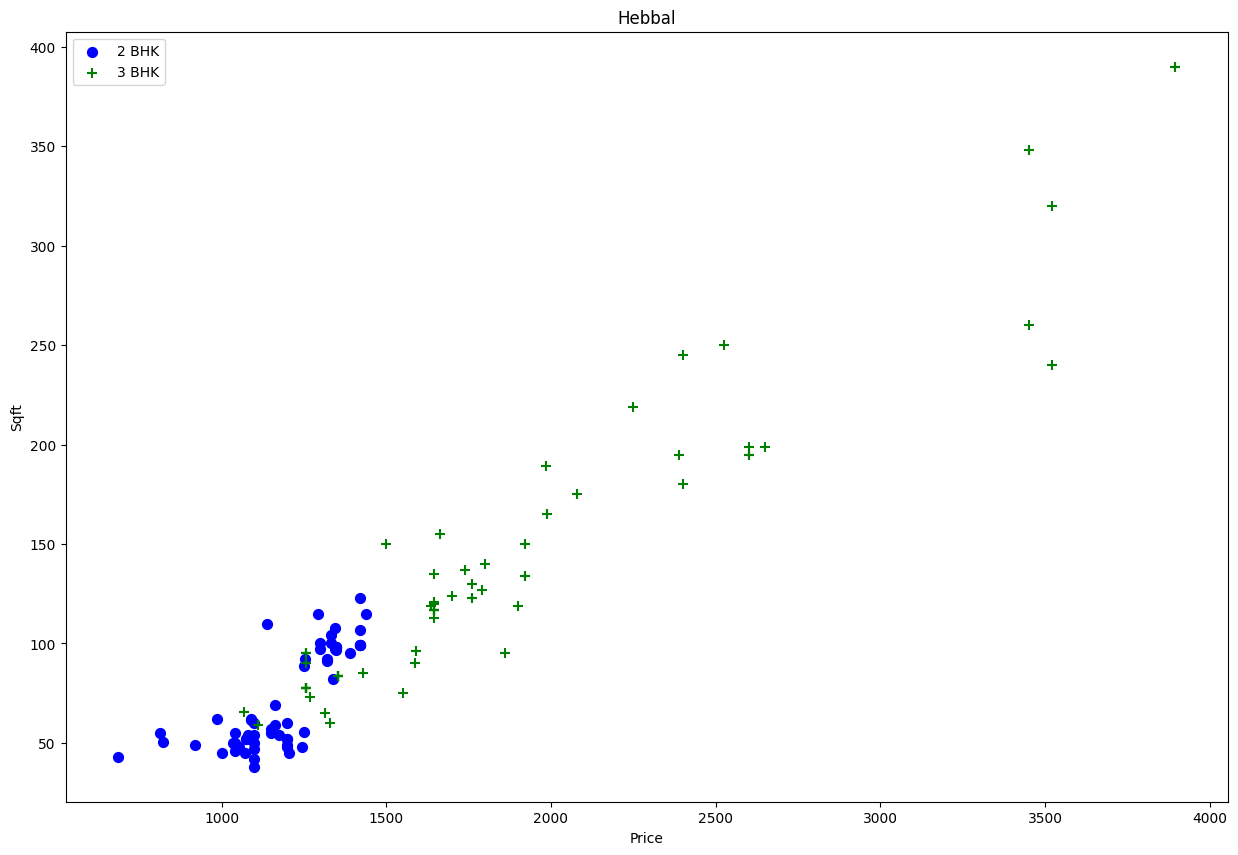

In [31]:
scatter_plot("Hebbal",df_new)

## 8. Outlier Removal (II): BHK Price Anomalies
Remove listings priced below the average for the prior BHK tier in the same location.

In [32]:
df_stats = df_new.groupby(["location", "Bedroom"])["price per sqft"].agg(['mean', 'count']).reset_index()
df_stats = df_stats.rename(columns={"mean": "mean_price_per_sqft_of_prev_bhk"})

df_new['prev_bhk_target'] = df_new['Bedroom'] - 1

df_merged = pd.merge(
    df_new,
    df_stats,
    how='left',
    left_on=["location", "prev_bhk_target"],
    right_on=["location", "Bedroom"]
)


drop_condition = (
    df_merged["price per sqft"] < df_merged["mean_price_per_sqft_of_prev_bhk"]
) & (df_merged["count"] > 5)

df_filtered = df_merged[~drop_condition].copy()

df_filtered = df_filtered.reset_index(drop=True)

In [33]:
df_filtered

,location,size,total_sqft,bath,price,Bedroom_x,sqft,price per sqft,prev_bhk_target,Bedroom_y,mean_price_per_sqft_of_prev_bhk,count
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2,1056.0,3699.810606,1,1.0,4786.716303,4.0
1,Uttarahalli,3 BHK,1440,2.0,62.00,3,1440.0,4305.555556,2,2.0,4189.826506,80.0
2,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3,1521.0,6245.890861,2,NaN,NaN,NaN
3,Kothanur,2 BHK,1200,2.0,51.00,2,1200.0,4250.000000,1,1.0,4892.344498,2.0
4,Old Airport Road,4 BHK,2732,4.0,204.00,4,2732.0,7467.057101,3,3.0,8401.781967,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8171,Uttarahalli,3 BHK,1345,2.0,57.00,3,1345.0,4237.918216,2,2.0,4189.826506,80.0
8172,Green Glen Layout,3 BHK,1715,3.0,112.00,3,1715.0,6530.612245,2,2.0,5548.844278,4.0
8173,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00,2,1141.0,5258.545136,1,1.0,4339.653067,5.0
8174,Padmanabhanagar,4 BHK,4689,4.0,488.00,4,4689.0,10407.336319,3,3.0,6103.133559,11.0


In [34]:
df_filtered.shape

(8176, 12)

## 9. Outlier Removal (III): Bathroom Count
Inspect distributions and drop listings with implausible bathroom counts.

Text(0.5, 1.0, 'Distribution')

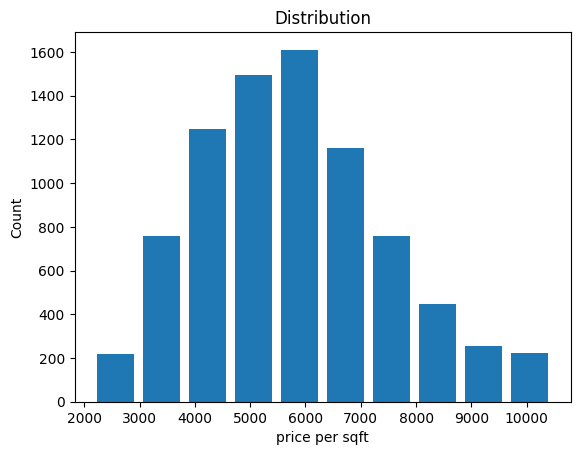

In [35]:
plt.hist(df_filtered["price per sqft"],rwidth=0.8)
plt.xlabel("price per sqft")
plt.ylabel("Count")
plt.title("Distribution")

In [36]:
df_filtered[df_filtered.bath > 10]

,location,size,total_sqft,bath,price,Bedroom_x,sqft,price per sqft,prev_bhk_target,Bedroom_y,mean_price_per_sqft_of_prev_bhk,count
1941,others,10 BHK,12000,12.0,525.0,10,12000.0,4375.000000,9,9.0,3670.752818,3.0
2251,others,16 BHK,10000,16.0,550.0,16,10000.0,5500.000000,15,NaN,NaN,NaN
4907,others,11 BHK,6000,12.0,150.0,11,6000.0,2500.000000,10,10.0,4375.000000,1.0
5314,Neeladri Nagar,10 BHK,4000,12.0,160.0,10,4000.0,4000.000000,9,NaN,NaN,NaN
6126,others,13 BHK,5425,13.0,275.0,13,5425.0,5069.124424,12,NaN,NaN,NaN


Text(0.5, 1.0, 'Distribution')

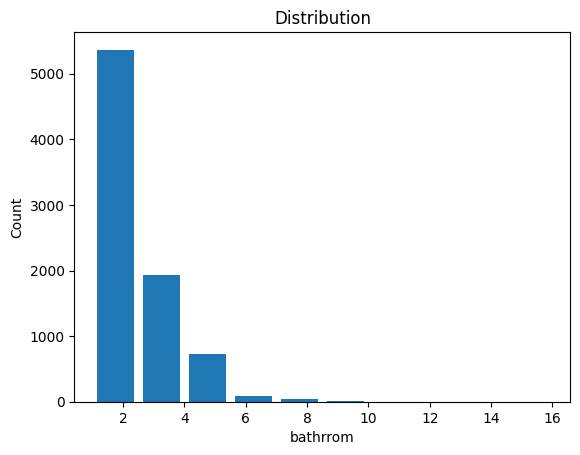

In [37]:
plt.hist(df_filtered["bath"],rwidth=0.8)
plt.xlabel("bathrrom")
plt.ylabel("Count")
plt.title("Distribution")

In [38]:
df_final=df_filtered[~(df_filtered.bath > df_filtered.Bedroom_x+2)].copy()

## 10. Finalize Dataset
Drop helper columns and rename to final feature names.

In [39]:
df_final.drop(columns=["size","total_sqft","price per sqft","prev_bhk_target","Bedroom_y","mean_price_per_sqft_of_prev_bhk","count"],axis=1,inplace=True)

In [40]:
df_final.rename(columns={"Bedroom_x":"bhk","sqft":"total_sqft"},inplace=True)

In [41]:
df_final.head()

,location,bath,price,bhk,total_sqft
0,Electronic City Phase II,2.0,39.07,2,1056.0
1,Uttarahalli,2.0,62.00,3,1440.0
2,Lingadheeranahalli,3.0,95.00,3,1521.0
3,Kothanur,2.0,51.00,2,1200.0
4,Old Airport Road,4.0,204.00,4,2732.0


## 11. One-Hot Encode Location

In [42]:
dummies=pd.get_dummies(df_final.location)
dummies.head()

,Devarachikkanahalli,1st Block Jayanagar,1st Block Koramangala,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,others
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [43]:
df_final=pd.concat([df_final,dummies.drop(columns=["others"])],axis=1)

In [44]:
df_final

,location,bath,price,bhk,total_sqft,Devarachikkanahalli,1st Block Jayanagar,1st Block Koramangala,1st Phase JP Nagar,2nd Phase Judicial Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,Electronic City Phase II,2.0,39.07,2,1056.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Uttarahalli,2.0,62.00,3,1440.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Lingadheeranahalli,3.0,95.00,3,1521.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Kothanur,2.0,51.00,2,1200.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Old Airport Road,4.0,204.00,4,2732.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8171,Uttarahalli,2.0,57.00,3,1345.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8172,Green Glen Layout,3.0,112.00,3,1715.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8173,Raja Rajeshwari Nagar,2.0,60.00,2,1141.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8174,Padmanabhanagar,4.0,488.00,4,4689.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [45]:
df_final.shape

(8172, 256)

## 12. Train / Test Split

In [46]:
X=df_final.drop(columns=["price","location"],axis=1)

In [47]:
y=df_final.price

## 13. Model Selection
Compare Linear Regression, Lasso, and Decision Tree Regressor via `GridSearchCV`.

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [49]:
from sklearn.linear_model import LinearRegression, Lasso
# 1. Swap the classifier for the regressor
from sklearn.tree import DecisionTreeRegressor

model_and_param = {
    'lr_reg': {
        'model': LinearRegression(),
        'param': {
            'fit_intercept': [True, False]
        }
    },
    'lasso': {
        'model': Lasso(),
        'param': {
            'alpha': [1, 2],
            'selection': ['random', 'cyclic']
        }
    },
    'DeTrReg': {
        'model': DecisionTreeRegressor(),
        'param': {
            'criterion': ['squared_error', 'friedman_mse'],
            'splitter': ['best', 'random']
        }
    }
}

In [50]:
scores=[]
for model,mp in model_and_param.items():
    clf=GridSearchCV(mp["model"],mp['param'],cv=5)
    clf.fit(X,y)
    scores.append({"Model":model,"Best_param":clf.best_params_,"Best_Score":clf.best_score_})
result=pd.DataFrame(scores,columns=["Model","Best_param","Best_Score"])
result

,Model,Best_param,Best_Score
0,lr_reg,{'fit_intercept': True},0.861461
1,lasso,"{'alpha': 1, 'selection': 'random'}",0.829494
2,DeTrReg,"{'criterion': 'squared_error', 'splitter': 'be...",0.791572


## 14. Fit Final Model

In [51]:
lr_reg=LinearRegression(fit_intercept=True)
lr_reg.fit(X,y)

LinearRegression()

## 15. Prediction Function

In [52]:
def predict_price(bath,bhk,total_sqft,location):
    loc_index=X.columns.get_loc(location)
    x=np.zeros(len(X.columns))
    x[0]=bath
    x[1]=bhk
    x[2]=total_sqft
    x[loc_index]=1
    input_df = pd.DataFrame([x], columns=X.columns)
    return lr_reg.predict(input_df)

In [53]:
predict_price(2,2,1500,"Vijayanagar")

array([100.18289414])

## 16. Save Model
Model is saved to `model/lr_reg_model.pickle`.

In [55]:
import joblib
joblib.dump(lr_reg,"lr_reg_model.pickle")

['lr_reg_model.pickle']